# 🕵️ Fake News Detector Project
**Group 14C:** Wynne Conger, Nina Elmoyan, Ramneek Kaur, Rhode Sanchez  
**AI4ALL Ignite - Fall 2024**

---

### 1. Setup & Configuration
Importing necessary libraries (Pandas, NLTK, Seaborn) and setting up our sentiment analyzers and word lists.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from pathlib import Path
from nltk.sentiment import SentimentIntensityAnalyzer
from better_profanity import profanity
from collections import Counter
from google import genai

# --- Download NLTK Resources ---
resources = ['punkt', 'stopwords', 'averaged_perceptron_tagger', 'vader_lexicon', 'punkt_tab']
for r in resources:
    try:
        nltk.data.find(f'tokenizers/{r}')
    except LookupError:
        print(f"Downloading {r}...")
        nltk.download(r, quiet=True)
        
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('averaged_perceptron_tagger')

# --- Initialize Tools ---
profanity.load_censor_words()
sia = SentimentIntensityAnalyzer()

# --- Define Word Lists ---
OPPOSITION_WORDS = {
    'but', 'however', 'although', 'though', 'yet', 'nevertheless', 
    'nonetheless', 'despite', 'instead', 'contradict', 'conversely'
}

FIRST_PERSON = {'i', 'we', 'me', 'us', 'my', 'our', 'mine', 'ours'}

SECOND_THIRD_PERSON = {
    'you', 'he', 'she', 'they', 'him', 'her', 'them', 
    'your', 'his', 'its', 'their'
}

LOADED_WORDS = {
    'radical', 'extreme', 'crisis', 'shocking', 'scandal', 'banned', 'exposed', 
    'secret', 'illegal', 'destroy', 'betray', 'panic', 'terror', 'myth', 'hoax',
    'conspiracy', 'freedom', 'tyranny', 'patriot', 'traitor', 'insane', 'plot'
}

BAD_WORDS_SET = {str(w).lower() for w in profanity.CENSOR_WORDSET if w}

print("✅ Setup Complete.")

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/ninaelmoyan/nltk_data...


✅ Setup Complete.


[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/ninaelmoyan/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


### 2. Feature Engineering (The "Identifiers")
Here we define the logic for our 12 key identifiers, including:
*   **Lexical Diversity:** Measuring vocabulary richness.
*   **Pronoun Analysis:** Comparing "I/We" vs "He/They".
*   **Readability:** Calculating average sentence length.
*   **POS Tagging:** Counting adjectives and verbs to detect subjectivity.

In [5]:
def get_lexical_diversity(text):
    """Calculates vocabulary richness (Unique/Total)."""
    if not isinstance(text, str): return 0
    tokens = nltk.word_tokenize(text.lower())
    words = [w for w in tokens if w.isalpha()]
    return len(set(words)) / len(words) if words else 0

def get_pronoun_counts(text):
    """Returns 1st vs 2nd/3rd person pronoun counts."""
    words = nltk.word_tokenize(str(text).lower())
    fp = sum(1 for w in words if w in FIRST_PERSON)
    stp = sum(1 for w in words if w in SECOND_THIRD_PERSON)
    return pd.Series([fp, stp], index=['pronoun_1st', 'pronoun_2nd_3rd'])

def get_readability_score(text):
    """Calculates Average Sentence Length (ASL). Higher = Harder."""
    if not isinstance(text, str) or not text: return 0
    sentences = nltk.sent_tokenize(text)
    words = nltk.word_tokenize(text)
    return len(words) / len(sentences) if sentences else 0

def get_pos_counts(text):
    """Counts Adjectives (subjectivity) and Verbs (action)."""
    if not isinstance(text, str) or not text: return 0, 0
    # Optimization: Only tag first 500 chars to save time
    tokens = nltk.word_tokenize(text[:500]) 
    tags = nltk.pos_tag(tokens)
    
    adj_count = len([t for w, t in tags if t.startswith('JJ')])
    verb_count = len([t for w, t in tags if t.startswith('VB')])
    return pd.Series([adj_count, verb_count], index=['pos_adjectives', 'pos_verbs'])

def analyze_ngrams(df, n=2, top_k=10):
    """Prints most common phrases."""
    print(f"\n--- 🔍 N-GRAM ANALYSIS (Top {top_k} Phrases) ---")
    for label_name, label_val in [("FAKE NEWS", 0), ("TRUE NEWS", 1)]:
        text_data = " ".join(df[df['label'] == label_val]['title'].astype(str))
        tokens = nltk.word_tokenize(text_data.lower())
        stop = set(nltk.corpus.stopwords.words('english'))
        tokens = [w for w in tokens if w.isalpha() and w not in stop]
        
        n_grams = list(nltk.ngrams(tokens, n))
        common = Counter(n_grams).most_common(top_k)
        
        print(f"\n[{label_name}]")
        for phrase, count in common:
            print(f"  {count}: {' '.join(phrase)}")

print("✅ Functions Loaded.")

✅ Functions Loaded.


### 3. Data Pipeline
Loading the `Fake.csv` and `True.csv` datasets, merging them, and running the feature extraction logic on all articles.
> **Note:** This step involves tokenizing 40,000+ articles and may take 1-2 minutes to complete.

In [6]:
# 1. Load Data
try:
    df_fake = pd.read_csv(Path("Dataset") / "Fake.csv")
    df_true = pd.read_csv(Path("Dataset") / "True.csv")
    df_fake['label'] = 0
    df_true['label'] = 1
    df = pd.concat([df_fake, df_true], ignore_index=True)
    print(f"✅ Data Loaded: {len(df)} articles.")
except FileNotFoundError:
    print("❌ Error: 'Dataset' folder not found.")

# 2. Extract Features
print("⚙️  Processing Text... (Please wait)")

# --- Simple Counts (Title & Text) ---
for col in ['title', 'text']:
    suffix = f"_{col}"
    # Word Count & Punctuation
    df[f'word_count{suffix}'] = df[col].apply(lambda x: len(str(x).split()))
    df[f'excl{suffix}'] = df[col].str.count('!')
    df[f'ques{suffix}'] = df[col].str.count(r'\?')
    # Sentiment
    df[f'sentiment{suffix}'] = df[col].apply(lambda x: sia.polarity_scores(str(x))['compound'])
    # Profanity & Loaded Words
    df[f'profanity{suffix}'] = df[col].apply(lambda x: sum(1 for w in str(x).lower().split() if w in BAD_WORDS_SET))
    df[f'loaded_vocab{suffix}'] = df[col].apply(lambda x: sum(1 for w in str(x).lower().split() if w in LOADED_WORDS))

# --- Complex Metrics ---
df['opposition_count'] = df['text'].apply(lambda x: sum(1 for w in str(x).lower().split() if w in OPPOSITION_WORDS))
df['lexical_diversity'] = df['text'].apply(get_lexical_diversity)
df['readability_score'] = df['text'].apply(get_readability_score)
df[['pronoun_1st', 'pronoun_2nd_3rd']] = df['text'].apply(get_pronoun_counts)

# --- POS Tagging ---
print("   ...Tagging Parts of Speech")
df[['pos_adjectives', 'pos_verbs']] = df['text'].apply(get_pos_counts)

print("✅ Processing Complete! Dataframe is ready.")

✅ Data Loaded: 44898 articles.
⚙️  Processing Text... (Please wait)
   ...Tagging Parts of Speech
✅ Processing Complete! Dataframe is ready.


### 4. Statistical Analysis & Visualization
Now that we have extracted the features, we analyze the correlation between these linguistic markers and the truthfulness of the article.

*   **Heatmap:** Shows which features correlate most strongly with Real News (Positive) vs Fake News (Negative).
*   **N-Grams:** Highlights the most common phrases used in titles for both categories.

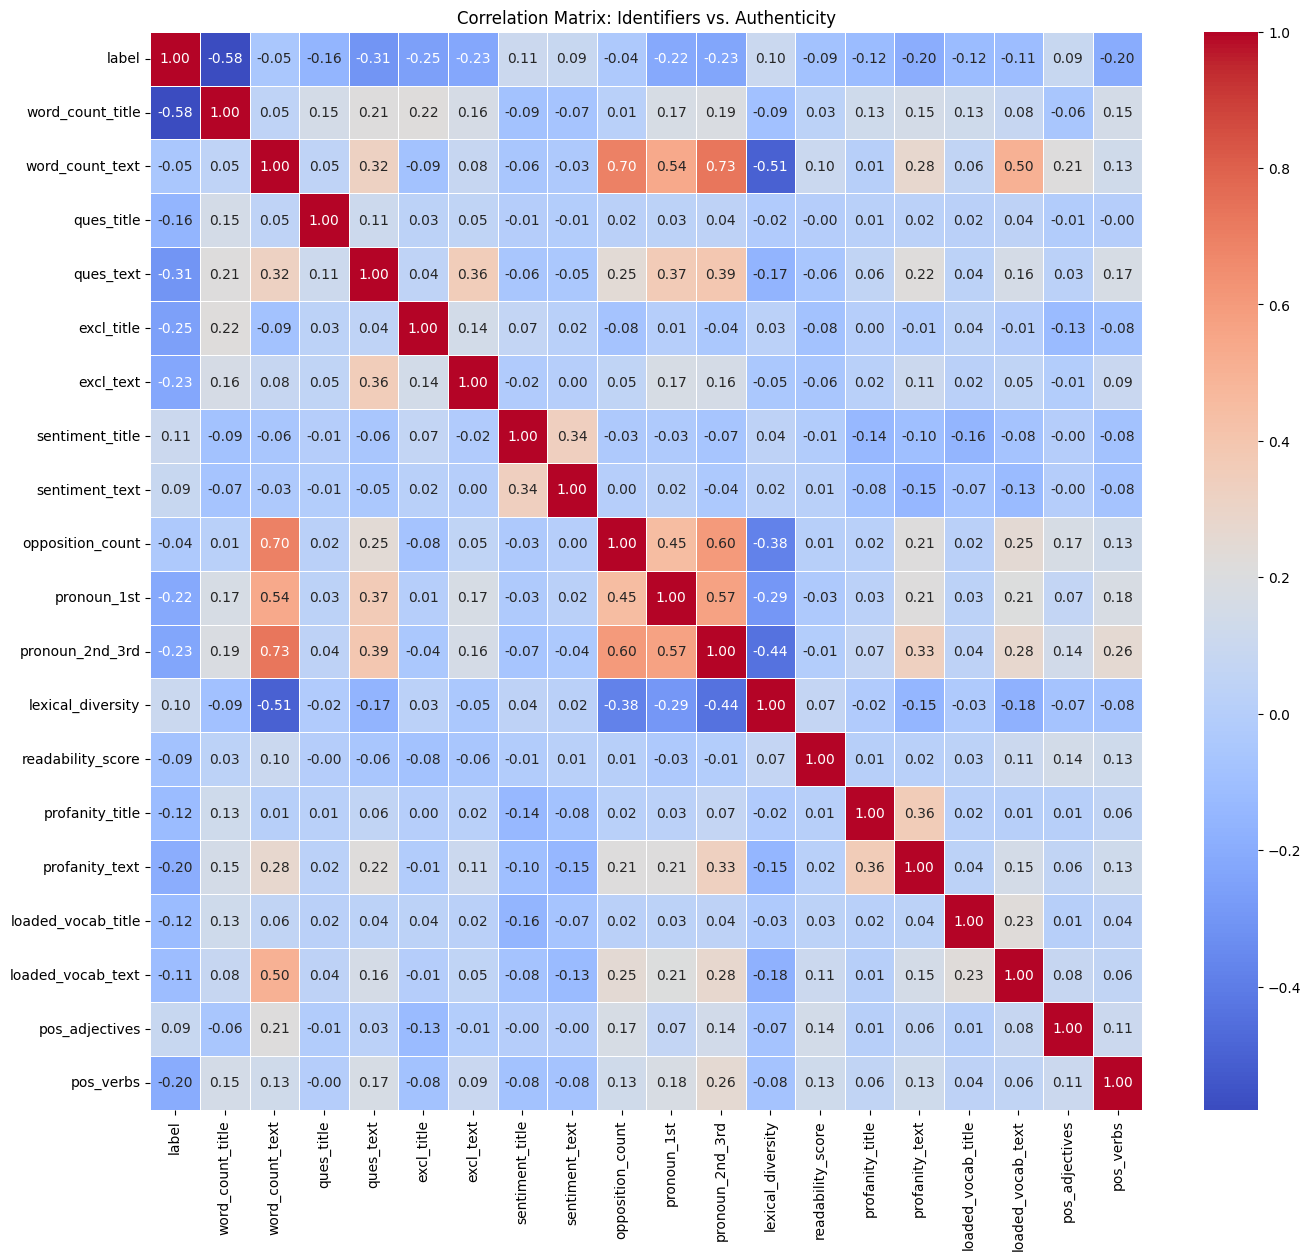


🏆 STRONGEST PREDICTORS OF FAKE NEWS (Negative Correlation):
word_count_title   -0.580489
ques_text          -0.307477
excl_title         -0.253718
pronoun_2nd_3rd    -0.232128
excl_text          -0.226820
Name: label, dtype: float64

🏆 STRONGEST PREDICTORS OF TRUE NEWS (Positive Correlation):
sentiment_title      0.109498
lexical_diversity    0.100239
sentiment_text       0.087099
pos_adjectives       0.086652
opposition_count    -0.036522
Name: label, dtype: float64

--- 🔍 N-GRAM ANALYSIS (Top 10 Phrases) ---

[FAKE NEWS]
  787: donald trump
  489: video watch
  478: president trump
  449: video trump
  403: hillary clinton
  328: white house
  305: fox news
  299: trump video
  268: video breaking
  253: bernie sanders

[TRUE NEWS]
  783: white house
  716: north korea
  364: trump says
  242: islamic state
  235: supreme court
  178: puerto rico
  156: travel ban
  155: says trump
  155: south korea
  148: trump administration


In [7]:
# 1. Define Features to Analyze
features = [
    'label', 
    'word_count_title', 'word_count_text',
    'ques_title', 'ques_text', 'excl_title', 'excl_text',
    'sentiment_title', 'sentiment_text',
    'opposition_count', 'pronoun_1st', 'pronoun_2nd_3rd',
    'lexical_diversity', 'readability_score',
    'profanity_title', 'profanity_text',
    'loaded_vocab_title', 'loaded_vocab_text',
    'pos_adjectives', 'pos_verbs'
]

# 2. Correlation Matrix
plt.figure(figsize=(16, 14))
corr = df[features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix: Identifiers vs. Authenticity')
plt.show()

# 3. Print Strongest Predictors
print("\n🏆 STRONGEST PREDICTORS OF FAKE NEWS (Negative Correlation):")
print(corr['label'].drop('label').sort_values().head(5))

print("\n🏆 STRONGEST PREDICTORS OF TRUE NEWS (Positive Correlation):")
print(corr['label'].drop('label').sort_values(ascending=False).head(5))

# 4. N-Gram Analysis
analyze_ngrams(df, n=2, top_k=10)